<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
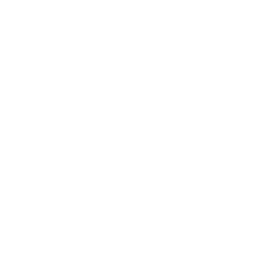
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ομαδοποίηση Ενεργειακής Απόδοσης Κτιρίων</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ενέργεια / Αναλυτική Βιωσιμότητας &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για τη Διοίκηση

Αυτό το παράδειγμα ομαδοποιεί ένα χαρτοφυλάκιο εμπορικών κτιρίων με βάση πέντε μετρικές ενεργειακής απόδοσης — Ένταση Ενεργειακής Χρήσης (EUI), λόγο απόδοσης HVAC, θερμική αντίσταση κελύφους, πυκνότητα ισχύος φωτισμού και ποσοστό ανανεώσιμης αντιστάθμισης — για να αναδείξει διακριτά επίπεδα απόδοσης με στόχο προγράμματα επιδότησης κοινής ωφέλειας. Η ανάλυση χρησιμοποιεί την **PROC FASTCLUS** με `REPLACE=FULL` (πλήρης αντικατάσταση σπόρων) και συγκρίνει τις λύσεις k=3, 4, 5 και 6 ως προς το συνολικό R-τετράγωνο, τη στατιστική ψευδο-F και το ελάχιστο μέγεθος ομάδας. Η λύση k=4 στη συνέχεια προφιλάρεται λεπτομερώς και κάθε ομάδα αντιστοιχίζεται σε ένα πρακτικά αξιοποιήσιμο επίπεδο απόδοσης. Επειδή αυτό το περιβάλλον εκτελείται χωρίς άδεια χρήσης, η επίδειξη περιορίζεται σε δείγμα 100 κτιρίων· το ίδιο πρόγραμμα κλιμακώνεται αμετάβλητο σε ολόκληρο το χαρτοφυλάκιο.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Ετήσιες μετρικές ενεργειακής απόδοσης ανά κτίριο (συνθετικά δεδομένα) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών ενεργειακών μετρικών κτιρίων
   Δείκτες ενεργειακής απόδοσης εμπορικών κτιρίων
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.building_metrics;
    CALL streaminit(42);
    LENGTH building_type $30;
    ARRAY regions[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    ΕΠΑΝΑΛΗΨΗ building_id = 1 ΕΩΣ 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        ΕΑΝ type_idx = 1 ΤΟΤΕ building_type = 'ΓΡΑΦΕΙΟ';
        ΑΛΛΙΩΣ ΕΑΝ type_idx = 2 ΤΟΤΕ building_type = 'ΕΜΠΟΡΙΚΟ';
        ΑΛΛΙΩΣ ΕΑΝ type_idx = 3 ΤΟΤΕ building_type = 'ΑΠΟΘΗΚΗ';
        ΑΛΛΙΩΣ ΕΑΝ type_idx = 4 ΤΟΤΕ building_type = 'ΝΟΣΟΚΟΜΕΙΟ';
        ΑΛΛΙΩΣ building_type = 'ΣΧΟΛΕΙΟ';
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Ένταση Ενεργειακής Χρήσης (kBtu/sqft/έτος) */
        eui = round(rand('normal', 85, 35), 0.1);
        ΕΑΝ eui < 15 ΤΟΤΕ eui = 15;
        ΕΑΝ eui > 250 ΤΟΤΕ eui = 250;

        /* Λόγος απόδοσης HVAC (ισοδύναμο COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        ΕΑΝ hvac_efficiency < 1.0 ΤΟΤΕ hvac_efficiency = 1.0;
        ΕΑΝ hvac_efficiency > 6.0 ΤΟΤΕ hvac_efficiency = 6.0;

        /* Θερμική αντίσταση κελύφους (τιμή R) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        ΕΑΝ envelope_r_value < 5 ΤΟΤΕ envelope_r_value = 5;
        ΕΑΝ envelope_r_value > 40 ΤΟΤΕ envelope_r_value = 40;

        /* Πυκνότητα ισχύος φωτισμού (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        ΕΑΝ lighting_wpf < 0.3 ΤΟΤΕ lighting_wpf = 0.3;
        ΕΑΝ lighting_wpf > 2.5 ΤΟΤΕ lighting_wpf = 2.5;

        /* Ποσοστό αντιστάθμισης ανανεώσιμης ενέργειας */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        ΕΑΝ renewable_pct > 80 ΤΟΤΕ renewable_pct = 80;

        /* Ηλικία κτιρίου σε έτη */
        building_age = int(rand('uniform') * 80) + 1;

        /* Επιφάνεια δαπέδου (χιλιάδες sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        ΕΑΝ floor_area_ksf > 500 ΤΟΤΕ floor_area_ksf = 500;

        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ type_idx reg_idx;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.74 seconds
  cpu   1.74 seconds


---

In [2]:
/* --------------------------------------------------------
   Βασικές κατανομές ενεργειακών μετρικών ανά τύπο κτιρίου
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.building_metrics n mean std;
    ΚΛΑΣΗ building_type;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ΕΤΙΚΕΤΑ building_type="Τύπος Κτιρίου" eui="Ένταση Ενεργειακής Χρήσης (EUI)"
          hvac_efficiency="Απόδοση HVAC" envelope_r_value="Θερμική Αντίσταση Κελύφους (R)"
          lighting_wpf="Πυκνότητα Ισχύος Φωτισμού" renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας";
    TITLE "Ενεργειακές Μετρικές ανά Τύπο Κτιρίου";
ΕΚΤΕΛΕΣΗ;

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          

                                                  The MEANS Procedure

                     Analysis Variable : eui Ένταση Ενεργειακής Χρήσης (EUI)

        Τύπος Κτιρίου                      N Obs           Mean        Std Dev
        ----------------------------------------------------------------------
        ΑΠΟΘΗΚΗ                               20     90.8900000     33.5993249
        ΓΡΑΦΕΙΟ                               20     73.0550000     40.3950163
        ΕΜΠΟΡΙΚΟ                              16     79.7312500     42.6818106
        ΝΟΣΟΚΟΜΕΙΟ                            25     87.9040000     35.2632892
        ΣΧΟΛΕΙΟ                               19     89.7000000     39.0498542
        ----------------------------------------------------------------------

                                Analysis Variable : hvac_efficiency Απόδοση HVAC

        Τύπος 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


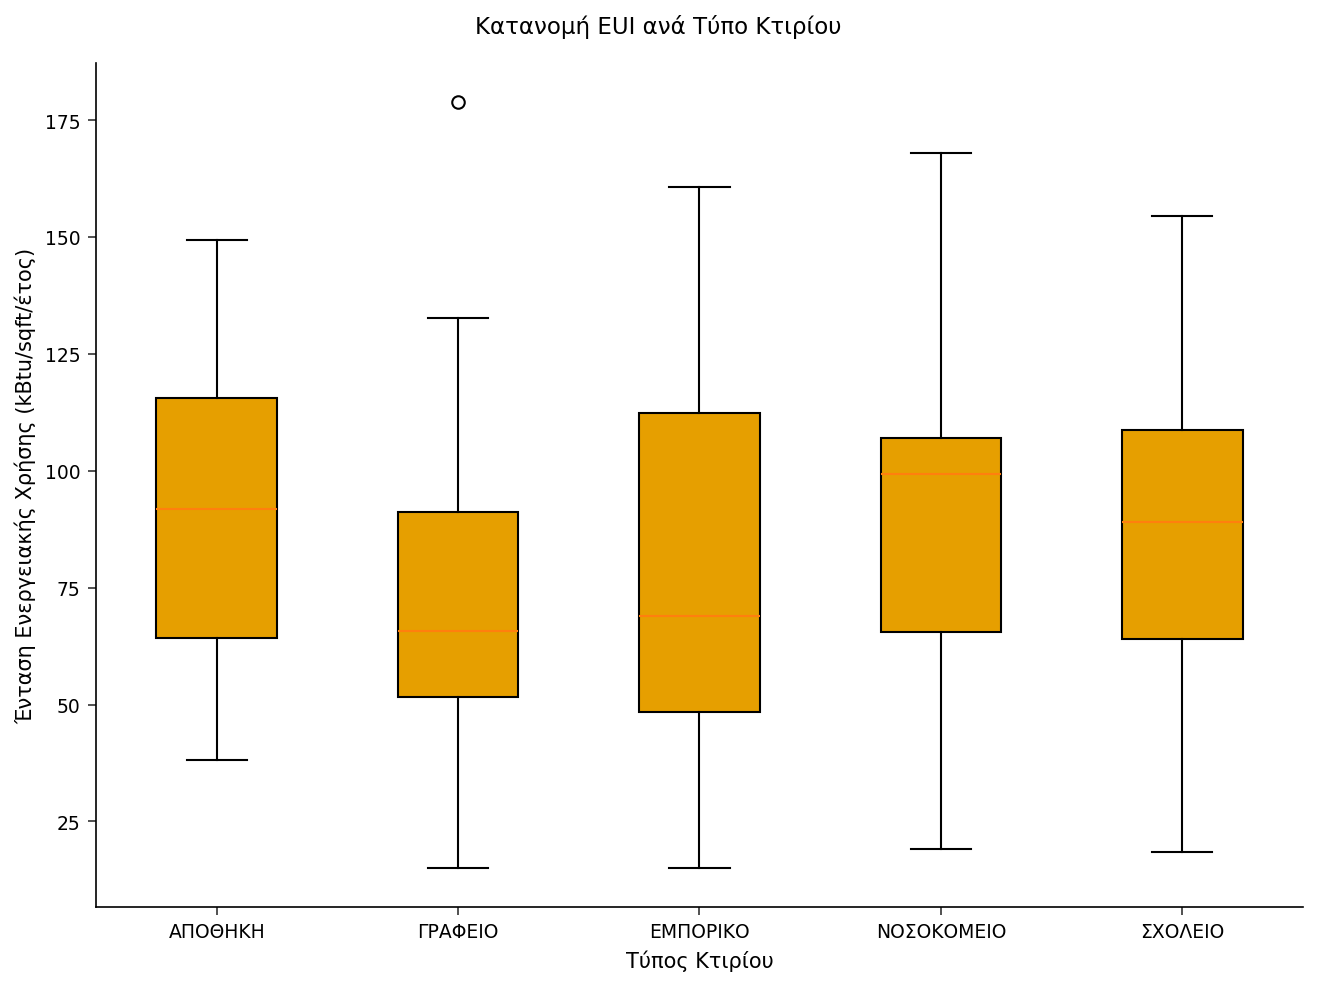

In [3]:
/* --------------------------------------------------------
   Κατανομή EUI ανά τύπο κτιρίου
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ΕΤΙΚΕΤΑ="Τύπος Κτιρίου";
    YAXIS ΕΤΙΚΕΤΑ="Ένταση Ενεργειακής Χρήσης (kBtu/sqft/έτος)";
    TITLE "Κατανομή EUI ανά Τύπο Κτιρίου";
ΕΚΤΕΛΕΣΗ;

---

In [4]:
/* --------------------------------------------------------
   Τυποποίηση μετρικών ενεργειακής απόδοσης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ STANDARD ΔΕΔΟΜΕΝΑ=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Ομαδοποίηση k-means: k=3 με REPLACE=FULL
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ΕΤΙΚΕΤΑ eui="Ένταση Ενεργειακής Χρήσης (EUI)" hvac_efficiency="Απόδοση HVAC"
          envelope_r_value="Θερμική Αντίσταση Κελύφους (R)" lighting_wpf="Πυκνότητα Ισχύος Φωτισμού"
          renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας";
    TITLE "Ομαδοποίηση Ενεργειακής Απόδοσης Κτιρίων: k=3 REPLACE=FULL";
ΕΚΤΕΛΕΣΗ;

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Ομαδοποίηση k-means: k=4 με REPLACE=FULL
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ΕΤΙΚΕΤΑ eui="Ένταση Ενεργειακής Χρήσης (EUI)" hvac_efficiency="Απόδοση HVAC"
          envelope_r_value="Θερμική Αντίσταση Κελύφους (R)" lighting_wpf="Πυκνότητα Ισχύος Φωτισμού"
          renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας";
    TITLE "Ομαδοποίηση Ενεργειακής Απόδοσης Κτιρίων: k=4 REPLACE=FULL";
ΕΚΤΕΛΕΣΗ;

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Ομαδοποίηση k-means: k=5 με REPLACE=FULL
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ΕΤΙΚΕΤΑ eui="Ένταση Ενεργειακής Χρήσης (EUI)" hvac_efficiency="Απόδοση HVAC"
          envelope_r_value="Θερμική Αντίσταση Κελύφους (R)" lighting_wpf="Πυκνότητα Ισχύος Φωτισμού"
          renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας";
    TITLE "Ομαδοποίηση Ενεργειακής Απόδοσης Κτιρίων: k=5 REPLACE=FULL";
ΕΚΤΕΛΕΣΗ;

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Ομαδοποίηση k-means: k=6 με REPLACE=FULL
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ FASTCLUS ΔΕΔΟΜΕΝΑ=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ΕΤΙΚΕΤΑ eui="Ένταση Ενεργειακής Χρήσης (EUI)" hvac_efficiency="Απόδοση HVAC"
          envelope_r_value="Θερμική Αντίσταση Κελύφους (R)" lighting_wpf="Πυκνότητα Ισχύος Φωτισμού"
          renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας";
    TITLE "Ομαδοποίηση Ενεργειακής Απόδοσης Κτιρίων: k=6 REPLACE=FULL";
ΕΚΤΕΛΕΣΗ;

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Σύγκριση ποιότητας ομαδοποίησης για k=3-6
   Υπολογισμός εντός-ομάδας R-τετράγωνου και ελάχιστου μεγέθους ομάδας
   -------------------------------------------------------- */
%macro cluster_quality(k);
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (RENAME=(count=n_buildings));
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SQL NOPRINT;
    ΕΠΙΛΟΓΗ MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          

                                         Ενεργειακές Μετρικές ανά Τύπο Κτιρίου                                          




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                         Προφίλ Επιπέδων Απόδοσης Κτιρίων (k=4)                                         

                                                  The MEANS Procedure

                                   Analysis Variable : eui Ένταση Ενεργειακής Χρήσης (EUI)

                                                   N
                                   Ομάδα         Obs             Mean         Std Dev
                                   --------------------------------------------------
                                   1              23       63.7782609      31.5423086
                                   2              17      122.5941176      36.0679995
                                   3              26       94.0076923      30.8825378
                                   4              34       72.3911765      31.7411154
                                   --------------------------------------------------

                                    Analysis Variable : hva


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


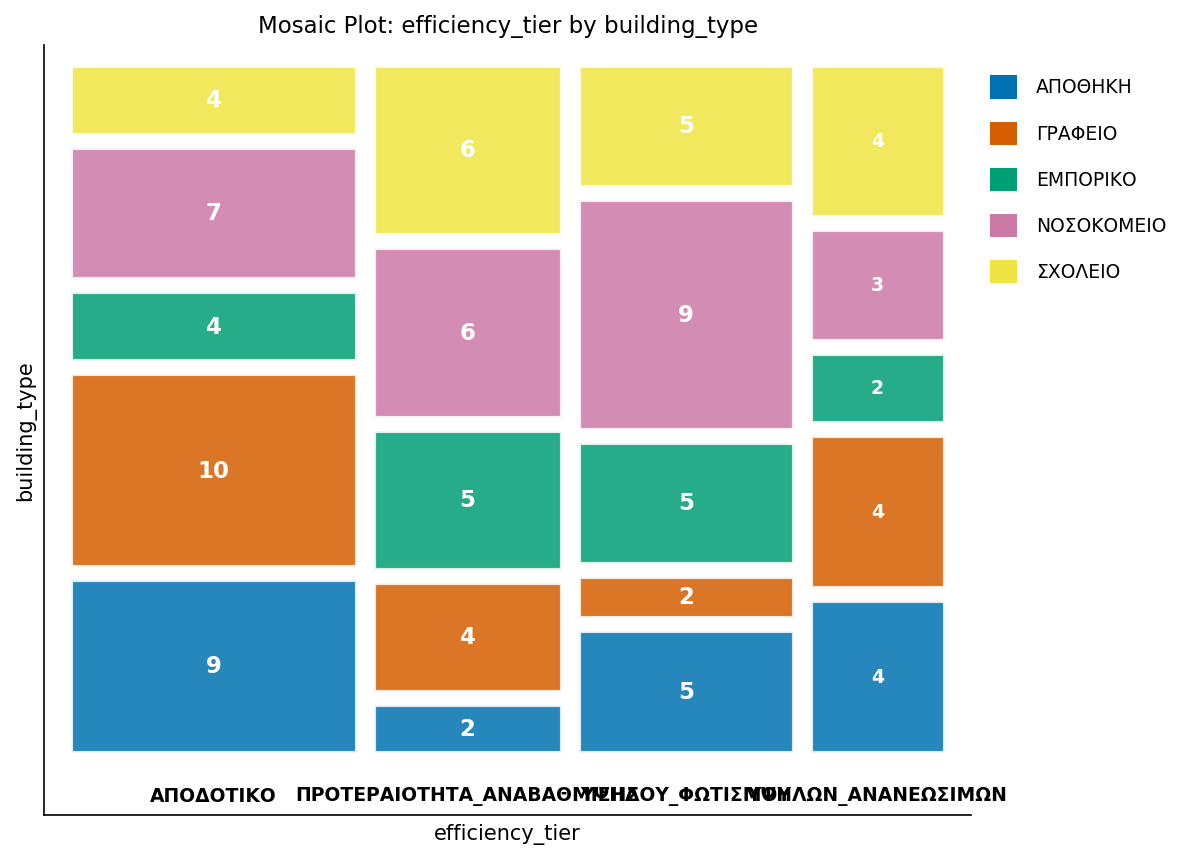

In [10]:
/* --------------------------------------------------------
   Προφίλ της επιλεγμένης λύσης k=4
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.bldg_profiled;
    ΣΥΓΧΩΝΕΥΣΗ work.building_metrics
          work.bldg_clust4 (ΚΡΑΤΗΣΗ=building_id CLUSTER distance);
    ΚΑΤΑ building_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.bldg_profiled mean std;
    ΚΛΑΣΗ CLUSTER;
    ΜΕΤΑΒΛΗΤΗ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ΕΤΙΚΕΤΑ CLUSTER="Ομάδα" eui="Ένταση Ενεργειακής Χρήσης (EUI)" hvac_efficiency="Απόδοση HVAC"
          envelope_r_value="Θερμική Αντίσταση Κελύφους (R)" lighting_wpf="Πυκνότητα Ισχύος Φωτισμού"
          renewable_pct="Ποσοστό Ανανεώσιμης Ενέργειας" building_age="Ηλικία Κτιρίου";
    TITLE "Προφίλ Επιπέδων Απόδοσης Κτιρίων (k=4)";
ΕΚΤΕΛΕΣΗ;

/* Ονομασία επιπέδων απόδοσης από τα παρατηρούμενα κέντρα του k=4:
   Ομάδα 4 = καλύτερο HVAC (3.89) σε χαμηλό EUI -> ΑΠΟΔΟΤΙΚΟ
   Ομάδα 2 = υψηλότερη ανανεώσιμη αντιστάθμιση (28%) αλλά υψηλότερο EUI -> ΥΨΗΛΩΝ_ΑΝΑΝΕΩΣΙΜΩΝ
   Ομάδα 3 = υψηλότερο φορτίο φωτισμού, ασθενές HVAC, μεσαίο EUI -> ΥΨΗΛΟΥ_ΦΩΤΙΣΜΟΥ
   Ομάδα 1 = χαμηλό EUI αλλά ασθενέστερο HVAC + λεπτότερο κέλυφος -> ΠΡΟΤΕΡΑΙΟΤΗΤΑ_ΑΝΑΒΑΘΜΙΣΗΣ */
ΔΕΔΟΜΕΝΑ work.bldg_tiered;
    ΟΡΙΣΜΟΣ work.bldg_profiled;
    LENGTH efficiency_tier $60;
    ΕΑΝ CLUSTER = 4 ΤΟΤΕ efficiency_tier = 'ΑΠΟΔΟΤΙΚΟ';
    ΑΛΛΙΩΣ ΕΑΝ CLUSTER = 2 ΤΟΤΕ efficiency_tier = 'ΥΨΗΛΩΝ_ΑΝΑΝΕΩΣΙΜΩΝ';
    ΑΛΛΙΩΣ ΕΑΝ CLUSTER = 3 ΤΟΤΕ efficiency_tier = 'ΥΨΗΛΟΥ_ΦΩΤΙΣΜΟΥ';
    ΑΛΛΙΩΣ ΕΑΝ CLUSTER = 1 ΤΟΤΕ efficiency_tier = 'ΠΡΟΤΕΡΑΙΟΤΗΤΑ_ΑΝΑΒΑΘΜΙΣΗΣ';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ΕΤΙΚΕΤΑ efficiency_tier="Επίπεδο Απόδοσης" building_type="Τύπος Κτιρίου";
    TITLE "Επίπεδο Απόδοσης ανά Τύπο Κτιρίου";
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

Με `REPLACE=FULL`, κάθε τιμή k συνέκλινε καθαρά. Στις τέσσερις λύσεις, το συνολικό R-τετράγωνο αυξήθηκε μονοτονικά με το k — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — ενώ η στατιστική ψευδο-F κορυφώθηκε στο **k=4 (22.23)** πριν μειωθεί (20.13 στο k=5, 19.93 στο k=6). Σε συνδυασμό με ελάχιστο μέγεθος ομάδας 17 κτιρίων στο k=4 (έναντι 13 στο k=5 και 10 στο k=6), η **λύση k=4** προσφέρει την καλύτερη ισορροπία διαχωρισμού και σταθερότητας επιπέδων, οπότε προφιλάρεται παρακάτω.

Οι τέσσερις ομάδες του k=4 αντιστοιχούν σε σαφώς διακριτά προφίλ απόδοσης (μέσοι όροι από το προφίλ PROC MEANS παραπάνω):

- **Αποδοτικό (Ομάδα 4, n=34):** η καλύτερα εξοπλισμένη ομάδα — υψηλότερη απόδοση HVAC (COP 3.89) σε χαμηλό προς μέτριο EUI 72.4 kBtu/sqft/έτος, με επαρκές κέλυφος (R 18.8) και μέτρια ανανεώσιμη αντιστάθμιση (11.0%).
- **Υψηλών ανανεώσιμων (Ομάδα 2, n=17):** οι υψηλότεροι απόλυτοι καταναλωτές (EUI 122.6) αλλά και μακράν η υψηλότερη ανανεώσιμη αντιστάθμιση (28.2%), με μέτρια απόδοση HVAC (COP 3.42). Υψηλή κατανάλωση σε συνδυασμό με επιτόπια παραγωγή.
- **Υψηλού φωτισμού (Ομάδα 3, n=26):** μέτριο EUI (94.0) που οδηγείται από την υψηλότερη πυκνότητα ισχύος φωτισμού (1.35 W/sqft) και τη δεύτερη ασθενέστερη απόδοση HVAC (COP 2.42), παρά το παχύτερο κέλυφος (R 19.6).
- **Προτεραιότητα αναβάθμισης (Ομάδα 1, n=23):** χαμηλό EUI στα χαρτιά (63.8) αλλά η ασθενέστερη απόδοση HVAC (COP 2.28) και το λεπτότερο κέλυφος (R 12.5) — κτίρια μικρά ή ελαφρώς χρησιμοποιούμενα αλλά κακώς εξοπλισμένα, οι σαφέστεροι υποψήφιοι για αναβαθμίσεις κελύφους και HVAC.

Η διασταύρωση επιπέδου-ανά-τύπο-κτιρίου δείχνει ότι τα γραφεία (10) και οι αποθήκες (9) κυριαρχούν στο αποδοτικό επίπεδο, ενώ τα νοσοκομεία συγκεντρώνονται στο επίπεδο υψηλού φωτισμού (9 από 26). Το επίπεδο προτεραιότητας αναβάθμισης είναι διάσπαρτο στους τύπους, με επικεφαλής τα νοσοκομεία και τα σχολεία (6 έκαστο από 23). Για τον σχεδιασμό προγραμμάτων, τα 23 κτίρια προτεραιότητας αναβάθμισης και τα 26 κτίρια υψηλού φωτισμού είναι οι φυσικοί στόχοι για κίνητρα HVAC και φωτισμού αντίστοιχα, ενώ τα 17 κτίρια υψηλών ανανεώσιμων — που ήδη παράγουν επιτόπια — ταιριάζουν καλύτερα σε μείωση ζήτησης παρά σε περαιτέρω επιδοτήσεις παραγωγής.

---

In [11]:
/* --------------------------------------------------------
   Εξαγωγή επιπέδων ενεργειακής απόδοσης κτιρίων και προφίλ κέντρων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>